#***ESTADÍSTICA INFERENCIAL***

![nombre alternativo](https://i.pinimg.com/originals/2d/3e/22/2d3e22e2d1a5dc3afc27dab67b72df62.gif)

###***Autor:*** *Solis Villafuerte Sebastian*

---

##### ***1-. ESTIMADORES Y ESTADÍSTICA INFERENCIAL***

La estadística inferencial tiene como objetivo extraer conclusiones sobre una población a partir de una muestra aleatoria representativa. Para ello, utiliza un estimador $\hat{\theta}$, definido como una función de la muestra, que permite aproximar el valor de un parámetro poblacional desconocido $\theta$.

$$\hat{\theta} = T(X_{1}, X_{2}, \dots, X_{n})$$

Sea una población con parámetros fijos $\mu$ y $\sigma^2$, y una muestra aleatoria $(X_1, X_2, \dots, X_n)$. A partir de esta muestra se definen los siguientes estadísticos muestrales:

$$\bar{X} = \frac{\sum x_i}{n} \quad , \quad s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$$

**Métodos de construcción de estimadores**

Existen diversos procedimientos analíticos para obtener funciones de la muestra que sirvan como estimadores de parámetros poblacionales:

**a) Método de momentos:** Consiste en igualar los momentos poblacionales con los momentos muestrales para aproximar parámetros desconocidos. El $n$-ésimo momento muestral se define como

$$m_{n} = \frac{1}{n} \sum_{i=1}^{n} X_{i}^{n}$$

**Ejemplo:** Hallar los estimadores para una muestra aleatoria $(X_{1}, ..., X_{n})$ que sigue una distribución Gamma con parámetros $(\alpha, \beta)$.

**Paso 1:** Identificamos la esperanza y varianza poblacional

$$E[X] = \frac{\alpha}{\beta} \quad , \quad Var(X) = \frac{\alpha}{\beta^2}$$

Y después, calculamos el segundo momento poblacional

$$E[X^2] = Var(X) + (E[X])^2 = \frac{\alpha}{\beta^2} + \frac{\alpha^2}{\beta^2}$$

**Paso 2:** Igualamos a los momentos muestrales

$$\frac{\alpha}{\beta} = \bar{X}$$

$$\frac{\alpha}{\beta^2} + \frac{\alpha^2}{\beta^2} = \frac{1}{n} \sum X_i^2$$

**Paso 3:** Despejamos $β$ de la primera ecuación ($\beta = \frac{\alpha}{\bar{X}}$) y sustituimos su valor en la segunda

$$\bar{X}^2 \left( \frac{1}{\alpha} + 1 \right) = m_2$$

 $$\frac{1}{\alpha} = \frac{m_2 - \bar{X}^2}{\bar{X}^2}$$

**Paso 4:** Finalmente, obtenemos los estimadores que dependen de los datos

$$\hat{\alpha} = \frac{\bar{X}^2}{m_2 - \bar{X}^2} = \frac{n\bar{X}^2}{\sum (X_i - \bar{X})^2} \qquad \text{y} \qquad \hat{\beta} = \frac{\bar{X}}{m_2 - \bar{X}^2} = \frac{n\bar{X}}{\sum (X_i - \bar{X})^2}$$

---

**b) Método de maxima verosimilitud:** Busca encontrar el valor del parámetro $\theta$ que maximiza la probabilidad de observar los datos muestrales.

Se utiliza la función de verosimilitud

$$L(\theta) = \prod_{i=1}^{n} f(x_i; \theta) = f(x_1; \theta) \cdot f(x_2; \theta) \cdots f(x_n; \theta)$$

Pero debido a que maximizar un producto es complejo, se suele aplicar el logaritmo natural para obtener la función de log-verosimilitud, transformando el producto en una suma

$$\ln(L(\theta)) = \sum_{i=1}^{n} \ln f(x_i; \theta)$$

**Ejemplo:** Sea una muestra aleatoria $(X_1, ..., X_n)$ que sigue una distribución Bernoulli con parámetro $p$. Hallaremos el estimador por MLE.

**Paso 1:** Para una variable Bernoulli, la función es

$$f(x; p) = p^x (1-p)^{1-x}$$

**Paso 2:** Por lo que, multiplicaremos la densidad para cada observación de la muestra

$$L(p) = \prod_{i=1}^{n} p^{x_i} (1-p)^{1-x_i} = p^{\sum x_i} (1-p)^{n - \sum x_i}$$

**Paso 3:** Transformamos la expresión para facilitar la derivación aplicando la funcion de log - verosimilitud

$$\ln(L(p)) = \left( \sum x_i \right) \ln(p) + \left( n - \sum x_i \right) \ln(1 - p)$$

**Paso 4:** Ahora, calculamos la derivada con respecto al parámetro $p$ para encontrar el punto máximo

$$\frac{d \ln(L(p))}{dp} = \frac{\sum x_i}{p} - \frac{n - \sum x_i}{1 - p} = 0$$

**Paso 5:** Por último, despejaremos la ecuación para hallar el estimador $\hat{p}$

$$\frac{\sum x_i}{p} = \frac{n - \sum x_i}{1 - p}$$

$$(1 - p) \sum x_i = p (n - \sum x_i)$$

$$\sum x_i - p \sum x_i = pn - p \sum x_i$$

$$\sum x_i = pn$$

El estimador de máxima verosimilitud $\hat{p}$ es equivalente a la media muestral:

$$\hat{p} = \frac{\sum x_i}{n} = \bar{X}$$

---

##### ***2-. DISTRIBUCIONES MUESTRALES***

Son las distribuciones de probabilidad de un estadístico (como la media o la varianza) calculado a partir de todas las muestras posibles de una población.

**a) Chi-cuadrada**

Esta distribución es el resultado natural de elevar variables normales al cuadrado y sumarlas.

Su definición formal es:

$$\text{Si } Z_1, Z_2, \dots, Z_n \sim N(0,1) \text{ son independientes, entonces: } \sum_{i=1}^{n} Z_i^2 \sim \chi_{(n)}^2$$

A diferencia de la normal, la $\chi^2$ solo existe en valores positivos (de 0 a $∞$) y tiene una marcada asimetría positiva, aunque esta se suaviza conforme aumentan sus grados de libertad (el número de valores independientes que la componen).

**Nota:** Es útil cuando el objetivo es realizar inferencia sobre la varianza poblacional ($\sigma^2$). Sin esta herramienta, no sería posible determinar qué tan dispersos están los datos respecto al modelo teórico.

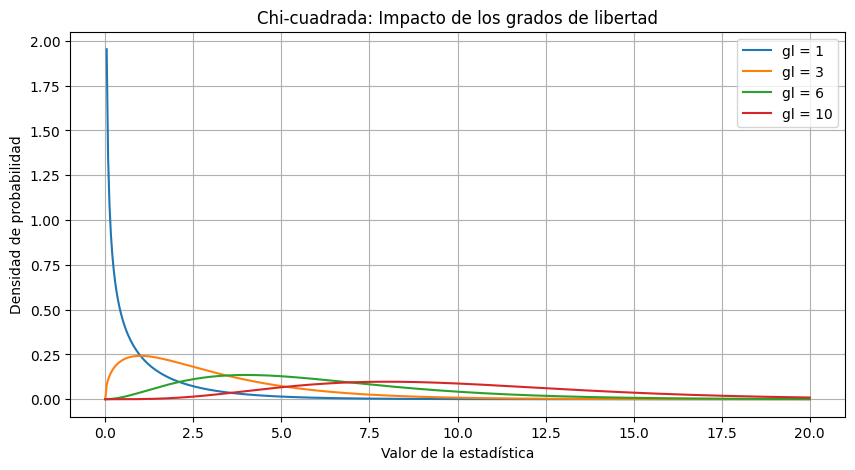

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import scipy.stats as st

x = np.linspace(0, 20, 500)
gl_chi = [1, 3, 6, 10]

plt.figure(figsize=(10, 5))
for gl in gl_chi:
    plt.plot(x, chi2.pdf(x, gl), label=f'gl = {gl}')

plt.title('Chi-cuadrada: Impacto de los grados de libertad')
plt.xlabel('Valor de la estadística')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid()
plt.show()

**b) T de Student**

Surge de una combinación entre el cociente de una variable normal estándar y la raíz de una chi-cuadrada. Visualmente es muy similar a la normal (es simétrica y centrada en cero), pero presenta colas más pesadas, lo que refleja una mayor incertidumbre.

$$T = \frac{Z}{\sqrt{W/n}} \sim t_{(n)}$$

**Nota:** Es útil cuando se desea estimar la media poblacional y no se conoce la desviación estándar real ($\sigma$), por lo que se utiliza la desviación estándar muestral ($s$). También es la base para comparar dos medias y realizar pruebas de significancia en regresión lineal. Además, cuando el tamaño de la muestra es grande ($n > 30$), esta distribución se aproxima a una normal estándar $N(0,1)$.

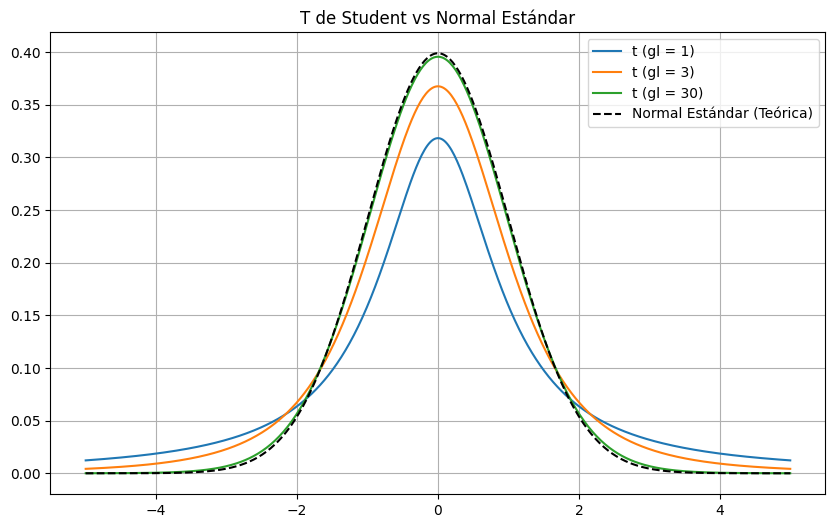

In [2]:
# @title
from scipy.stats import t, norm

x_t = np.linspace(-5, 5, 500)
gl_t = [1, 3, 30]

plt.figure(figsize=(10, 6))
for gl in gl_t:
    plt.plot(x_t, t.pdf(x_t, gl), label=f't (gl = {gl})')

plt.plot(x_t, norm.pdf(x_t), 'k--', label='Normal Estándar (Teórica)')

plt.title('T de Student vs Normal Estándar')
plt.legend()
plt.grid()
plt.show()

**c) F de Fisher**

Se define como el cociente de dos variables chi-cuadrada independientes, cada una dividida por sus respectivos grados de libertad. Por ello, su forma depende de dos parámetros: los grados de libertad del numerador y los del denominador.

$$F = \frac{W_1/m}{W_2/n} \sim F_{(m,n)}$$

En el contexto de muestras, se utiliza para comparar varianzas mediante la fórmula:

$$F = \frac{s_1^2 / \sigma_1^2}{s_2^2 / \sigma_2^2} \sim F_{(n_1-1, n_2-1)}$$

**Nota:** Además, es la pieza central del análisis ANOVA, que permite determinar si las diferencias entre varios grupos son reales o simplemente producto del azar.

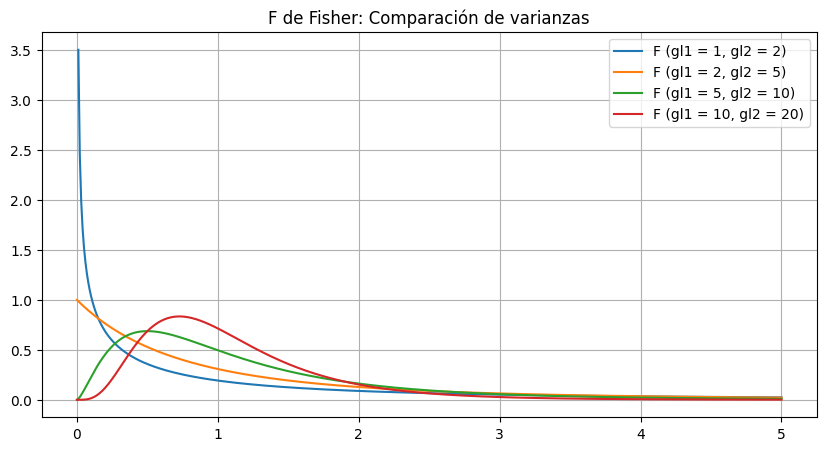

In [3]:
# @title
from scipy.stats import f

x_f = np.linspace(0, 5, 500)
parametros_f = [(1, 2), (2, 5), (5, 10), (10, 20)]

plt.figure(figsize=(10, 5))
for d1, d2 in parametros_f:
    plt.plot(x_f, f.pdf(x_f, d1, d2), label=f'F (gl1 = {d1}, gl2 = {d2})')

plt.title('F de Fisher: Comparación de varianzas')
plt.legend()
plt.grid()
plt.show()

---

##### ***3-. INTERVALOS DE CONFIANZA***

Se define como un rango de valores, construido a partir de una muestra aleatoria, que tiene una probabilidad específica (denominada nivel de confianza $\gamma$ o $1-\alpha$) de contener el verdadero parámetro poblacional desconocido, como la media ($\mu$) o la varianza ($\sigma^2$). Este rango se determina mediante estadísticos muestrales que actúan como límites inferiores y superiores ($T_1$ y $T_2$), calculados de tal forma que la probabilidad de que el parámetro se encuentre entre ellos sea igual al nivel de confianza elegido (comúnmente el $95\%$).

La precisión de este intervalo depende directamente del error estándar (SE), el cual mide la variabilidad del estimador. Un aspecto crítico en el diseño experimental es que, a mayor tamaño de muestra ($n$), el error estándar disminuye, lo que resulta en un intervalo más estrecho y una estimación más precisa del parámetro.

**Estimación de la media poblacional ($\mu$)**

Para construir un intervalo de confianza para la media en poblaciones normales, el procedimiento varía según el conocimiento de la varianza poblacional y el tamaño de la muestra.

- **Varianza conocida ($\sigma^2$):** Se utiliza la distribución Normal estándar ($Z$), aplicando la fórmula

$$IC = \left( \bar{X} \pm Z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right)$$

- **Varianza desconocida:** Si el tamaño de la muestra es pequeño ($n \le 30$), se debe emplear la distribución t de Student con $n-1$ grados de libertad para compensar la incertidumbre de estimar la varianza con los datos muestrales

$$IC = \left( \bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}} \right)$$

Si la muestra es grande ($n > 30$), es posible recurrir nuevamente a la distribución normal estándar debido al teorema del límite central.

**Estimación de la Varianza Poblacional ($\sigma^2$)**

Para realizar inferencias sobre la dispersión de los datos (la varianza), se utiliza la distribución Chi-cuadrada ($\chi^2$). El intervalo se construye utilizando la varianza muestral ($s^2$) y los valores críticos de la tabla Chi-cuadrada para $n-1$ grados de libertad, siguiendo la estructura:

$$\left( \frac{(n-1)s^2}{\chi_{\alpha/2, n-1}^2} < \sigma^2 < \frac{(n-1)s^2}{\chi_{1-\alpha/2, n-1}^2} \right)$$

**Ejemplo:** Un restaurante desea optimizar su inventario y presupuestos operativos. Para ello, necesita conocer el gasto promedio real de todos sus clientes. Sin embargo, es imposible preguntar a cada persona que ha visitado el lugar. En su lugar, el gerente toma una muestra de 49 clientes y registra sus consumos. El objetivo es pasar de un dato promedio simple a un rango de confianza que represente fielmente a toda la clientela.

**Paso 1:** Primero, debemos identificar los datos conocidos de la población y la muestra. En este caso, asumimos que conocemos la variabilidad general del mercado (desviación estándar poblacional $\sigma$).

- Tamaño de muestra ($n$): 49

- Desviación estándar poblacional ($\sigma$): 2.5
- Media muestral ($\bar{X}$): 22.60
- Nivel de confianza: 95% ($\alpha = 0.05$)

**Paso 2:** Después, se calcula el error estándar (SE), que indica cuánto se espera que varíe la media muestral respecto a la media real de la población.

In [4]:
n = 49
sigma = 2.5
media_muestral = 22.60

In [5]:
error_estandar = sigma / np.sqrt(n)
print(f"El error estándar es de: {error_estandar:.4f}")

El error estándar es de: 0.3571


Para un nivel de confianza del 95%, buscamos los valores críticos de la distribución Normal ($Z$) que encierran el área central de la curva. El margen de error será el producto de este valor crítico por el error estándar calculado anteriormente.

**Paso 3:** Utilizamos la función `st.norm.interval` para obtener directamente los límites inferior y superior del gasto promedio.

In [6]:
nivel_confianza = 0.95

In [7]:
intervalo = st.norm.interval(nivel_confianza, loc=media_muestral, scale=error_estandar)

In [8]:
print(f"Intervalo de confianza (95%): ({intervalo[0]:.2f}, {intervalo[1]:.2f})")

Intervalo de confianza (95%): (21.90, 23.30)


Basándonos en este análisis, podemos afirmar con un 95% de certeza que el gasto promedio de cualquier cliente que entre al restaurante se encuentra entre \$21.90 y \$23.30. Este rango permite al gerente realizar proyecciones financieras mucho más seguras que si solo usara el promedio de $22.60

---

#***EJERCICIOS***

![nombre alternativo](https://i.pinimg.com/originals/57/57/92/57579220d7d0f823f50719300b9cc65c.gif)

##### ***EJERCICIO 1: ESTIMACIÓN DE UNA MONEDA (BINOMIAL)***

Supongamos que lanzamos una moneda $n = 100$ veces y obtenemos $55$ "soles". Queremos hallar el Estimador de Máxima Verosimilitud (EMV) para la probabilidad $p$.

Si $X \sim \text{Bin}(100, p)$, la función de probabilidad es

$$f_X(x; p) = \binom{100}{55} p^{55} (1-p)^{100-55}$$

Importamos las herramientas necesarias

In [9]:
import sympy
import numpy as np
from sympy.abc import p
from scipy.stats import binom
from sympy.abc import theta

Definimos $p$ como variable simbólica positiva y la función de verosimilitud (omitimos la constante combinatoria)

In [10]:
p_sym = sympy.symbols('p', positive = True)

In [11]:
f = p_sym**55 * (1 - p_sym)**(100 - 55)

Derivamos con respecto a $p$

In [12]:
df = sympy.diff(f, p_sym)

Igualamos a cero y resolvemos para $p$

In [13]:
phat = sympy.solve(df, p_sym)
print(f"El estimador es: {phat[0]}")

El estimador es: 11/20


**Nota:** El MLE en Bernoulli / Binomial siempre es la proporción muestral.

##### ***EJERCICIO 2: SIMULACIÓN DE BERNOULLI Y PRODUCTO DE VEROSIMILITUD***

Simularemos una muestra de tamaño $n=100$ con una probabilidad real $p=0.7$ y calcularemos el EMV basándonos en los datos generados.

Generamos $100$ observaciones de una Bernoulli $(p = 0.7)$

In [14]:
r = binom.rvs(n=1, p=0.7, size=100)

Definimos los símbolos y la verosimilitud para una sola observación simbólica

In [15]:
x = sympy.symbols('x')
p_sym = sympy.symbols('p_sym', positive=True, real=True)

In [16]:
f_ind = p_sym**x * (1 - p_sym)**(1-x)

Calculamos el producto de verosimilitud de toda la muestra

In [17]:
J = np.prod([f_ind.subs(x, i) for i in r])

Aplicamos logaritmo y simplificamos $($usamos $force = True$ para asegurar que aplique las reglas de $log(a*b) = log(a) + log(b)$$)$

In [18]:
log_L = sympy.expand_log(sympy.log(J), force=True)

Resolvemos la derivada del logaritmo igualada a cero

In [19]:
phat_sim = sympy.solve(sympy.diff(log_L, p_sym), p_sym)
print(f"El estimador para p es: {phat_sim[0]}")

El estimador para p es: 13/20


##### ***EJERCICIO 3: TIEMPO DE RETARDO DE EMERGENCIAS***

Un hospital recibe pacientes con síntomas coronarios. El tiempo que tardan en llegar a urgencias varía mucho. Para mejorar la logística, el hospital necesita estimar el tiempo promedio de espera de toda su población basándose solo en los primeros 20 pacientes.

Para este problema utilizaremos el método de momentos, ya que resulta una forma intuitiva de estimar el parámetro. Dado que, en teoría, el promedio poblacional es $1/\theta$, igualamos este valor al promedio observado en los datos para obtener la estimación.

Asumimos que el tiempo sigue una distribución exponencial, $X \sim \text{Exp}(\theta)$, y igualamos el primer momento poblacional, $E[X] = 1/\theta$, con la media muestral, $\bar{X}$.

**Datos:** Minutos transcurridos para 20 pacientes

In [20]:
datos_emergencia = np.array([525, 719, 2880, 150, 30, 251, 45, 858, 15, 47,
                             90, 56, 68, 6, 189, 180, 60, 60, 294, 747])

**Aplicamos la lógica:** El promedio de la muestra es nuestro mejor candidato al promedio real

In [21]:
media_muestral = np.mean(datos_emergencia)
theta_hat = 1 / media_muestral

In [22]:
print(f"La media estimada de espera es de {media_muestral} minutos")

La media estimada de espera es de 363.5 minutos


In [23]:
print(f"La tasa estimada de llegada (theta) es de {theta_hat:.5f} pacientes / min")

La tasa estimada de llegada (theta) es de 0.00275 pacientes / min


##### ***EJERCICIO 4: VIDA ÚTIL DE FOCOS***

Una fábrica de focos asegura que sus productos duran años. Probamos 5 focos y duran $\{2, 3, 1, 3, 5\}$ años. Queremos hallar la tasa de falla $\theta$ que sea más probable dado que observamos exactamente esos datos.

A diferencia de los momentos, el método MLE no solo busca el promedio; busca el valor de $\theta$ que maximiza la probabilidad de que nuestra muestra haya ocurrido. Es matemáticamente más "robusto" para muestras pequeñas.

Definimos la función de verosimilitud ($L$) como el producto de las probabilidades asociadas a cada foco. Por ejemplo, si un foco dura 2 años y otro 5, buscamos el valor de $\theta$ que haga que la ocurrencia conjunta de ambos tiempos sea lo más probable posible.

$$L(\theta) = \prod_{i=1}^{n} \theta e^{-\theta x_i} = \theta^n e^{-\theta \sum x_i}$$

In [24]:
theta_sym = sympy.symbols('theta', positive=True)
datos_focos = [2, 3, 1, 3, 5]
n = len(datos_focos)

Como derivar productos es difícil, aplicamos logaritmos para convertir el problema en una suma.

$$\ln L(\theta) = n \ln(\theta) - \theta \sum x_i$$

In [25]:
log_L = n * sympy.log(theta_sym) - theta_sym * sum(datos_focos)

Derivamos respecto a $\theta$ e igualamos a cero para encontrar el "pico" de la montaña (el máximo).

$$\frac{d \ln L(\theta)}{d\theta} = \frac{n}{\theta} - \sum x_i = 0$$

In [26]:
derivada = sympy.diff(log_L, theta_sym)
mle_theta = sympy.solve(derivada, theta_sym)[0]

In [27]:
print(f"El valor de theta que hace más probables estos datos es de {float(mle_theta):.4f}")

El valor de theta que hace más probables estos datos es de 0.3571


In [28]:
print(f"Con una vida media estimada de {1/float(mle_theta):.1f} años")

Con una vida media estimada de 2.8 años


Este método nos dice que, para esos focos, la tasa más creíble es de $0.3571$ fallas por año. Si hubiéramos usado otro $\theta$, la probabilidad de ver esos datos exactos sería menor.

##### ***EJERCICIO 5: ESTIMACIÓN DE PARÁMETROS EN DISTRIBUCIÓN NORMAL***

Disponemos de una muestra pequeña de 15 datos ($n=15$) provenientes de una población normal. Necesitamos estimar la media y la variabilidad de la población bajo diferentes escenarios de información.

**a) Escenario A:** Construcción un intervalo de confianza al 90% para $\mu$, suponiendo que $\sigma = 2$.

**Nota:** Cuando conocemos la desviación estándar poblacional, usamos la distribución Normal ($Z$), incluso con muestras pequeñas.

In [29]:
datos = np.array([1.2, 2.1, 2.3, 1.9, 3.0, 1.5, 2.8, 2.4, 1.7, 2.6, 2.0, 1.8, 3.1, 2.2, 2.5])

In [30]:
n = len(datos)
media_muestral = np.mean(datos)
sigma_conocida = 2
confianza = 0.90

In [31]:
se_a = sigma_conocida / np.sqrt(n)
ic_a = st.norm.interval(confianza, loc=media_muestral, scale=se_a)

In [32]:
print(f"El intervalo de confianza es: ({ic_a[0]:.2f}, {ic_a[1]:.2f})")

El intervalo de confianza es: (1.36, 3.06)


**b) Escenario B:** Construcción un intervalo de confianza al 90% para $\mu$.

**Nota:** Al no conocer $\sigma$, debemos usar la desviación estándar de la muestra ($s$) y la distribución t de Student, que compensa el error de estimación.

In [33]:
s_muestral = np.std(datos, ddof=1)

In [34]:
se_b = s_muestral / np.sqrt(n)
ic_b = st.t.interval(confianza, df=n-1, loc=media_muestral, scale=se_b)

In [35]:
print(f"El intervalo de confianza es: ({ic_b[0]:.2f}, {ic_b[1]:.2f})")

El intervalo de confianza es: (1.96, 2.45)


**c) Escenario C:** Construcción un intervalo de confianza al 90% para $\sigma^2 = 2$.

**Nota:** Para estimar qué tan dispersos están los datos en la población, usamos la distribución Chi-cuadrada.

In [36]:
alpha = 1 - confianza
gl = n - 1
s2 = np.var(datos, ddof=1)

In [37]:
chi_inf = st.chi2.ppf(alpha / 2, gl)
chi_sup = st.chi2.ppf(1 - alpha / 2, gl)

In [38]:
ic_var = ((gl * s2) / chi_sup, (gl * s2) / chi_inf)

In [39]:
print(f"El intervalo de confianza es: ({ic_var[0]:.3f}, {ic_var[1]:.3f})")

El intervalo de confianza es: (0.175, 0.631)


##### ***EJERCICIO 6: CONTROL DE CALIDAD AUTOMOTRIZ***

La encuesta anual de calidad de automóviles, realizada por J. D. Power & Associates, reportó que el número promedio de defectos por vehículo nuevo, considerando todas las marcas, es de 1.07 (The Wall Street Journal, 27 de enero de 1994). Suponga que se toma una muestra de 30 automóviles nuevos de una marca específica y se registran las siguientes cantidades de defectos por vehículo:

In [40]:
defectos = np.array([0, 1, 1, 2, 1, 0, 2, 3, 2, 1, 0, 2, 0, 0, 2, 3, 0, 4, 3, 1, 1, 1, 0, 2, 0, 2, 0, 3, 1, 0])

**a)** ¿Cuál es el promedio muestral de la cantidad de defectos por vehículo?

In [41]:
media_d = np.mean(defectos)
std_d = np.std(defectos, ddof=1)

In [42]:
print(f"Promedio muestral de defectos: {media_d:.2f}")

Promedio muestral de defectos: 1.27


**b)** ¿Cuál es la desviación estándar de la muestra?

In [43]:
print(f"Desviación estándar muestral: {std_d:.2f}")

Desviación estándar muestral: 1.17


**c)** Determine un intervalo de confianza del 95% para la media de defectos por vehículo de esta marca.

**Nota:** Con $n=30$, estamos justo en el límite del Teorema del Límite Central. Utilizaremos la distribución $t$ para ser más conservadores y precisos.

In [44]:
n_d = len(defectos)
se_d = std_d / np.sqrt(n_d)
ic_d = st.t.interval(0.95, df=n_d-1, loc=media_d, scale=se_d)

In [45]:
print(f"El intervalo de confianza para defectos es de: ({ic_d[0]:.2f}, {ic_d[1]:.2f})")

El intervalo de confianza para defectos es de: (0.83, 1.70)


**d)** Un analista sugirió que se debería revisar una muestra mayor antes de comparar con el promedio general de J.D. Power (1.07). ¿Respalda usted esta idea? ¿Por qué?

Sí, el promedio de la marca es consistente con el promedio de la industria, ya que el valor 1.07 se encuentra dentro del intervalo de confianza del 95%. Por lo tanto, no hay evidencia suficiente para afirmar que esta marca difiere del promedio general. En otras palabras, no se puede concluir que la marca analizada sea distinta al resto del mercado.

##### ***EJERCICIO 7: ANÁLISIS DE SALARIOS (NYT 1988 ALMANAC)***

De acuerdo con el The New York Times 1988 Almanac, el ingreso semanal promedio de las personas que trabajan en el sector servicios es de \$369. Suponga que este valor se obtuvo a partir de una muestra de 250 personas y que la desviación estándar muestral es de $50.

Construya un intervalo de confianza del 95% para la media poblacional del ingreso semanal en el sector servicios.

Identificamos los componentes clave:

- Media muestral ($\bar{X}$): \$369.

- Tamaño de muestra ($n$): 250 personas.

- Desviación estándar de la muestra ($s$): \$50.

Aunque no conocemos la desviación poblacional ($\sigma$), el tamaño de la muestra es grande ($n = 250$, que es $> 30$). Según el Teorema del Límite Central, podemos utilizar la distribución Normal (Z) para obtener un intervalo preciso.

In [46]:
n = 250
media_muestral = 369
desv_est_muestral = 50
confianza = 0.95

In [47]:
error_estandar = desv_est_muestral / np.sqrt(n)

In [48]:
print(f"El error estándar es de: {error_estandar:.4f}")

El error estándar es de: 3.1623


Para construir el intervalo, sumamos y restamos a la media un margen de error. Este margen se obtiene multiplicando el valor crítico $Z$ (para un nivel de confianza del 95%) por el error estándar.

In [49]:
intervalo_ingresos = st.norm.interval(confianza, loc=media_muestral, scale=error_estandar)

In [50]:
print(f"El intervalo de confianza del 95% es: (${intervalo_ingresos[0]:.2f}, ${intervalo_ingresos[1]:.2f})")

El intervalo de confianza del 95% es: ($362.80, $375.20)


Con un 95% de confianza, podemos afirmar que el ingreso semanal promedio verdadero para todos los trabajadores del sector servicios en 1988 se encontraba entre $\$362.80$ y $\$375.20$.

Este resultado es muy sólido debido a que el tamaño de muestra de 250 personas es lo suficientemente grande como para que el margen de error sea pequeño, lo que le da mucha credibilidad al dato reportado por el Almanac.